# Verification of Local L-smoothness

### Objective

The objective of this experiment is to empirically estimate the local Lipschitz constant of the gradient around the trained model parameters.

A function is locally L-smooth if its gradient satisfies

$$
\|\nabla f(\theta+\delta)-\nabla f(\theta)\|
\le
L\|\delta\|.
$$

The local Lipschitz constant is estimated as

$$
\hat L=
\frac{\|\nabla f(\theta+\delta)-\nabla f(\theta)\|}
{\|\delta\|},
$$

where \(\delta\) is a small random perturbation of the model parameters.

### Methodology

The verification is performed as follows:

1. Load the trained model.
2. Compute the gradient using a fixed mini-batch.
3. Apply a small random perturbation to all trainable parameters.
4. Recompute the gradient.
5. Estimate the local Lipschitz constant.
6. Repeat the experiment multiple times and analyze the distribution of the estimated values.

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm 

from src.utils import load_config
from src.data import get_dataloaders
from manual_nn.models import SimpleCNN

import torch
from torch.nn import CrossEntropyLoss
import torch.nn.functional as F

os.environ["CUDA_VISIBLE_DEVICES"] = "7"

In [4]:
config = load_config(os.path.join(PROJECT_ROOT, "configs/data.yaml"))
model_cfg = load_config(os.path.join(PROJECT_ROOT, "configs/model.yaml"))

CHECKPOINT_PATH = os.path.join(PROJECT_ROOT, "checkpoints/best_model.pth")
def load_checkpoint(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)

    layer_id = 0
    for layer in model.layers:
        if hasattr(layer, "weights"):
            layer.weights = checkpoint[f"layer_{layer_id}.weights"].to(device)
            layer.bias = checkpoint[f"layer_{layer_id}.bias"].to(device)
            layer_id += 1

    print(f"Loaded {layer_id} parameter layers from {checkpoint_path}")
    return model



model = SimpleCNN(model_cfg)
model = load_checkpoint(model, CHECKPOINT_PATH, 'cpu')
loss_fn = CrossEntropyLoss()

loader,_,_ = get_dataloaders(data_dir=config["root"],batch_size=256,shuffle=False)
x,y = next(iter(loader))

Loaded 4 parameter layers from /vision01_scratch/rajat/et-robo/problem1_mnist/checkpoints/best_model.pth


In [5]:
def compute_gradient(model, x, y):

    model.zero_grad()

    logits = model.forward(x)
    probs = F.softmax(logits, dim=1)
    targets = F.one_hot(y, num_classes=model_cfg["num_classes"]).float()
    grad_logits = (probs - targets) / y.size(0)

    model.backward(grad_logits)

    grad = torch.cat([
        g.flatten()
        for g in model.gradients()
    ])

    return grad

g_ref = compute_gradient(model, x, y)

print(f"Gradient dimension: {g_ref.numel():,}")
print(f"Gradient norm: {torch.norm(g_ref):.4f}")

Gradient dimension: 409,034
Gradient norm: 1.1674


In [6]:
import copy
from tqdm import tqdm

epsilon = 1e-4
num_trials = 200

L_values = []

for _ in tqdm(range(num_trials)):

    perturbed_model = copy.deepcopy(model)

    delta_norm_sq = 0.0

    for layer in perturbed_model.layers:

        if hasattr(layer, "weights"):

            delta_w = epsilon * torch.randn_like(layer.weights)
            delta_b = epsilon * torch.randn_like(layer.bias)

            layer.weights += delta_w
            layer.bias += delta_b

            delta_norm_sq += torch.sum(delta_w ** 2)
            delta_norm_sq += torch.sum(delta_b ** 2)

    g_new = compute_gradient(perturbed_model, x, y)

    grad_diff = torch.norm(g_new - g_ref)
    delta_norm = torch.sqrt(delta_norm_sq)

    L_hat = grad_diff / delta_norm

    L_values.append(L_hat.item())

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:15<00:00, 13.32it/s]


### Step 4: Estimate the Local Lipschitz Constant

For each random perturbation, the local Lipschitz constant is estimated as

$$
\hat L=
\frac{\|\nabla f(\theta+\delta)-\nabla f(\theta)\|}
{\|\delta\|}.
$$

If the estimated values remain finite and exhibit low variability across multiple perturbations, the objective function behaves consistently with a locally L-smooth function around the trained solution.

In [7]:
L_values = np.array(L_values)

print(f"Number of Trials : {len(L_values)}")
print(f"Mean L           : {L_values.mean():.4f}")
print(f"Std L            : {L_values.std():.4f}")
print(f"Min L            : {L_values.min():.4f}")
print(f"Max L            : {L_values.max():.4f}")

Number of Trials : 200
Mean L           : 0.2726
Std L            : 0.1252
Min L            : 0.0577
Max L            : 0.6666


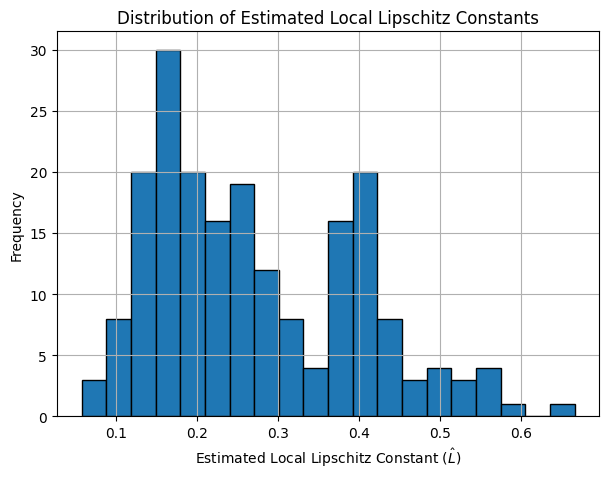

In [8]:
plt.figure(figsize=(7,5))

plt.hist(L_values, bins=20, edgecolor="black")

plt.xlabel(r"Estimated Local Lipschitz Constant ($\hat{L}$)")
plt.ylabel("Frequency")
plt.title("Distribution of Estimated Local Lipschitz Constants")
plt.grid(True)

plt.show()

### What does this figure tell?

The estimated local Lipschitz constants are concentrated within a finite range, indicating that small perturbations in the model parameters lead to proportionally small changes in the gradient. This suggests that the objective function behaves approximately as a locally L-smooth function around the trained solution. Since the estimates are obtained only in the neighborhood of the converged parameters, they provide empirical evidence of **local** smoothness rather than a proof of global L-smoothness.

### Conclusion

The local Lipschitz constant was estimated by measuring the change in gradients under small random perturbations of the trained model parameters. The estimated values remained finite across all perturbations, indicating stable local gradient behavior. Therefore, the optimization objective exhibits empirical evidence consistent with **local L-smoothness** around the trained solution. However, this experiment does not establish global L-smoothness, which would require bounding the Hessian over the entire parameter space.